In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/README.md
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/18184.dat
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/19090.dat
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/18177.dat
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/16773.dat
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/19830.dat
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/16786.dat
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/19090.hea
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/17453.dat
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/16272.hea
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/16265.dat
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/18177.hea
/kaggle/input/private-dataset/ECG_MIT-BIH_SIN_Holter/nsrdb_250hz/16273.dat
/kaggle/input/private-dataset/ECG_MIT

In [2]:
!pip install -q wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.5 MB/s eta 0:00:00


In [3]:
# ============================================================
# Install Missing Packages (Kaggle Safe)
# ============================================================

import sys
import subprocess

def install(package):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", package]
    )

try:
    import pywt
except ImportError:
    install("PyWavelets")
    import pywt


# ============================================================
# Standard Libraries
# ============================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# Numerical Libraries
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# Plotting
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# Image Processing
# ============================================================

from PIL import Image


# ============================================================
# Signal Processing
# ============================================================

from scipy.interpolate import interp1d


# ============================================================
# Progress Bar
# ============================================================

from tqdm.auto import tqdm


print("="*60)
print("Notebook 6 : Wavelet Scalogram Generation")
print("PyWavelets Version :", pywt.__version__)
print("="*60)

Notebook 6 : Wavelet Scalogram Generation
PyWavelets Version : 1.8.0


In [4]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random Seed :", SEED)

Random Seed : 42


In [5]:
# ============================================================
# Dataset Paths
# ============================================================

DATA_ROOT = "/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset"

OUTPUT_ROOT = "/kaggle/working/Wavelet_Dataset"

prediction_windows = [30,25,20,15,10,5]

os.makedirs(
    OUTPUT_ROOT,
    exist_ok=True
)

print("Input :", DATA_ROOT)
print("Output:", OUTPUT_ROOT)

Input : /kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset
Output: /kaggle/working/Wavelet_Dataset


In [6]:
# ============================================================
# Configuration
# ============================================================

FS = 250

SEGMENT_LENGTH = 500

IMAGE_SIZE = (224,224)

LEAD = 0

SCALES = np.arange(1,129)

CWT_WAVELET = "cmor1.5-1.0"

DENOISE_WAVELET = "sym4"

THRESHOLD = 0.04

print("Sampling Rate :", FS)
print("Segment Length :", SEGMENT_LENGTH)
print("Image Size :", IMAGE_SIZE)
print("Lead :", LEAD)
print("CWT Wavelet :", CWT_WAVELET)
print("Denoising Wavelet :", DENOISE_WAVELET)

Sampling Rate : 250
Segment Length : 500
Image Size : (224, 224)
Lead : 0
CWT Wavelet : cmor1.5-1.0
Denoising Wavelet : sym4


In [7]:
# ============================================================
# Load Dataset
# ============================================================

def load_dataset(minute):

    folder = os.path.join(
        DATA_ROOT,
        f"{minute}_min"
    )

    X = np.load(
        os.path.join(folder,"X.npy")
    )

    y = np.load(
        os.path.join(folder,"y.npy")
    )

    return X,y

In [8]:
# ============================================================
# Verify Dataset
# ============================================================

X,y = load_dataset(30)

print("ECG Shape :",X.shape)
print("Labels Shape :",y.shape)

print()

print("Positive Samples :",np.sum(y==1))
print("Negative Samples :",np.sum(y==0))

print()

print("One ECG Shape :",X[0].shape)
print("ECG Data Type :",X.dtype)

print("Minimum :",X.min())
print("Maximum :",X.max())

ECG Shape : (2400, 500, 2)
Labels Shape : (2400,)

Positive Samples : 1200
Negative Samples : 1200

One ECG Shape : (500, 2)
ECG Data Type : float64
Minimum : -5.605
Maximum : 3.53


In [9]:
# ============================================================
# Repair ECG (NaN / Inf Interpolation)
# ============================================================

def repair_ecg(ecg):
    """
    Repair NaN / Inf values independently for each ECG lead.

    Parameters
    ----------
    ecg : ndarray
        Shape = (500, 2)

    Returns
    -------
    ndarray
        Repaired ECG
    """

    ecg = ecg.astype(np.float64).copy()

    for lead in range(ecg.shape[1]):

        signal = ecg[:, lead]

        invalid = ~np.isfinite(signal)

        if np.sum(invalid) == 0:
            continue

        valid_index = np.where(~invalid)[0]

        if len(valid_index) < 2:

            signal[:] = 0

        else:

            interpolator = interp1d(
                valid_index,
                signal[valid_index],
                kind="linear",
                fill_value="extrapolate"
            )

            signal[invalid] = interpolator(
                np.where(invalid)[0]
            )

        ecg[:, lead] = signal

    return ecg

In [10]:
# ============================================================
# ECG Wavelet Denoising
# Paper:
# Wavelet = sym4
# Threshold = 0.04
# ============================================================

def denoise_ecg(signal):
    """
    Wavelet denoising exactly as described in the paper.
    """

    max_level = pywt.dwt_max_level(
        len(signal),
        pywt.Wavelet(DENOISE_WAVELET).dec_len
    )

    coeffs = pywt.wavedec(
        signal,
        wavelet=DENOISE_WAVELET,
        level=max_level
    )

    coeffs = [
        pywt.threshold(
            c,
            THRESHOLD,
            mode="soft"
        )
        for c in coeffs
    ]

    denoised = pywt.waverec(
        coeffs,
        DENOISE_WAVELET
    )

    return denoised[:len(signal)]

In [11]:
# ============================================================
# Generate Wavelet Scalogram
# ============================================================

def generate_scalogram(signal):
    """
    Generate Continuous Wavelet Transform scalogram.

    Returns
    -------
    ndarray
        Shape = (128, 500)
    """

    coefficients, frequencies = pywt.cwt(
        signal,
        scales=SCALES,
        wavelet=CWT_WAVELET,
        sampling_period=1/FS
    )

    scalogram = np.abs(coefficients)

    return scalogram.astype(np.float32)

In [12]:
# ============================================================
# Normalize Scalogram
# ============================================================

def normalize_scalogram(scalogram):
    """
    Log normalization for CNN/ViT input.
    """

    scalogram = np.log1p(scalogram)

    scalogram -= scalogram.min()

    if scalogram.max() > 0:
        scalogram /= scalogram.max()

    return scalogram.astype(np.float32)

In [13]:
# ============================================================
# Test Complete Wavelet Pipeline
# ============================================================

sample = repair_ecg(X[0])

signal = sample[:, LEAD]

signal = denoise_ecg(signal)

scalogram = generate_scalogram(signal)

scalogram = normalize_scalogram(scalogram)

print("Signal Shape :", signal.shape)
print("Scalogram Shape :", scalogram.shape)

print("Minimum :", scalogram.min())
print("Maximum :", scalogram.max())

Signal Shape : (500,)
Scalogram Shape : (128, 500)
Minimum : 0.0
Maximum : 1.0


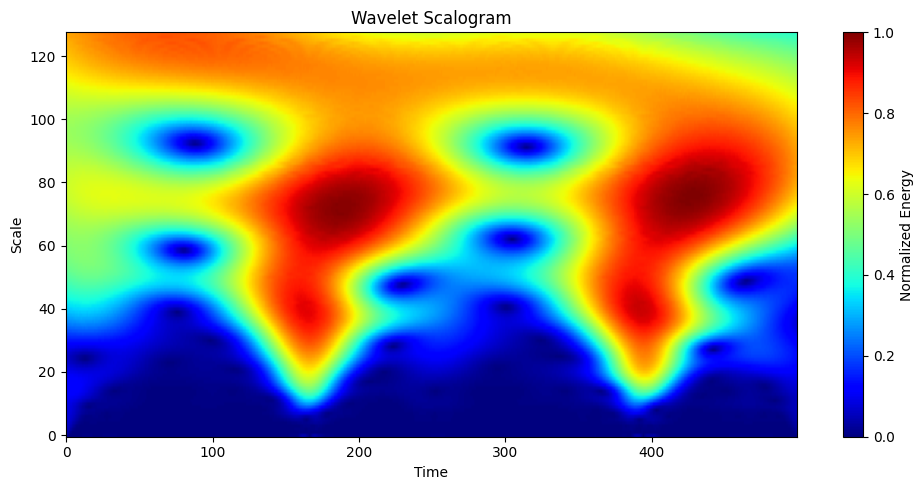

In [14]:
# ============================================================
# Visualize Scalogram
# ============================================================

plt.figure(figsize=(10,5))

plt.imshow(
    scalogram,
    origin="lower",
    aspect="auto",
    cmap="jet"
)

plt.title("Wavelet Scalogram")

plt.xlabel("Time")

plt.ylabel("Scale")

plt.colorbar(label="Normalized Energy")

plt.tight_layout()

plt.show()

In [15]:
# ============================================================
# Create Output Directories
# ============================================================

for minute in prediction_windows:

    os.makedirs(
        os.path.join(
            OUTPUT_ROOT,
            f"{minute}_min",
            "Positive"
        ),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(
            OUTPUT_ROOT,
            f"{minute}_min",
            "Negative"
        ),
        exist_ok=True
    )

print("Output folders created successfully.")

Output folders created successfully.


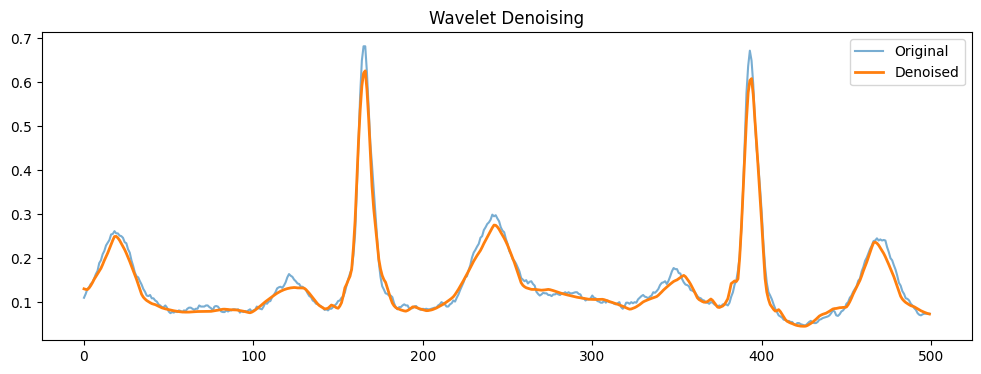

In [16]:
##################





plt.figure(figsize=(12,4))

plt.plot(sample[:, LEAD], label="Original", alpha=0.6)

plt.plot(signal, label="Denoised", linewidth=2)

plt.legend()

plt.title("Wavelet Denoising")

plt.show()

In [17]:
coefficients, frequencies = pywt.cwt(
    signal,
    scales=SCALES,
    wavelet=CWT_WAVELET,
    sampling_period=1/FS
)

print(coefficients.shape)
print(frequencies.shape)

print(frequencies[:10])

(128, 500)
(128,)
[250.         125.          83.33333333  62.5         50.
  41.66666667  35.71428571  31.25        27.77777778  25.        ]


In [18]:
print(coefficients.min())
print(coefficients.max())

print(np.isnan(coefficients).sum())

print(np.isinf(coefficients).sum())

(-0.36623977637822325-0.006496388881732345j)
(0.3542772036109945-0.0051006113257145175j)
0
0


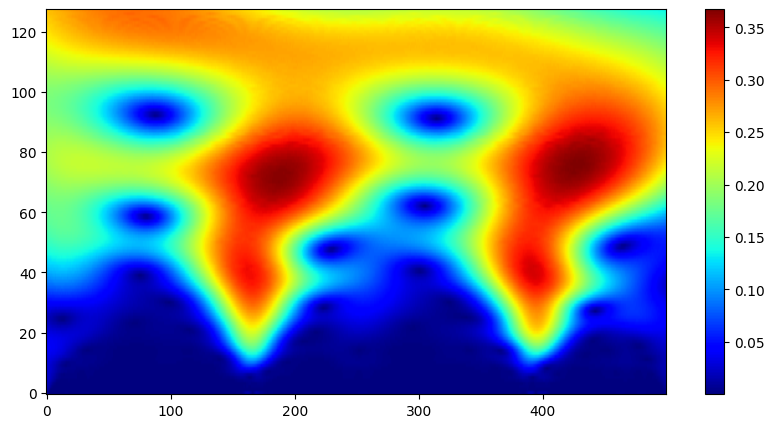

In [19]:
plt.figure(figsize=(10,5))

plt.imshow(
    np.abs(coefficients),
    aspect="auto",
    origin="lower",
    cmap="jet"
)

plt.colorbar()

plt.show()

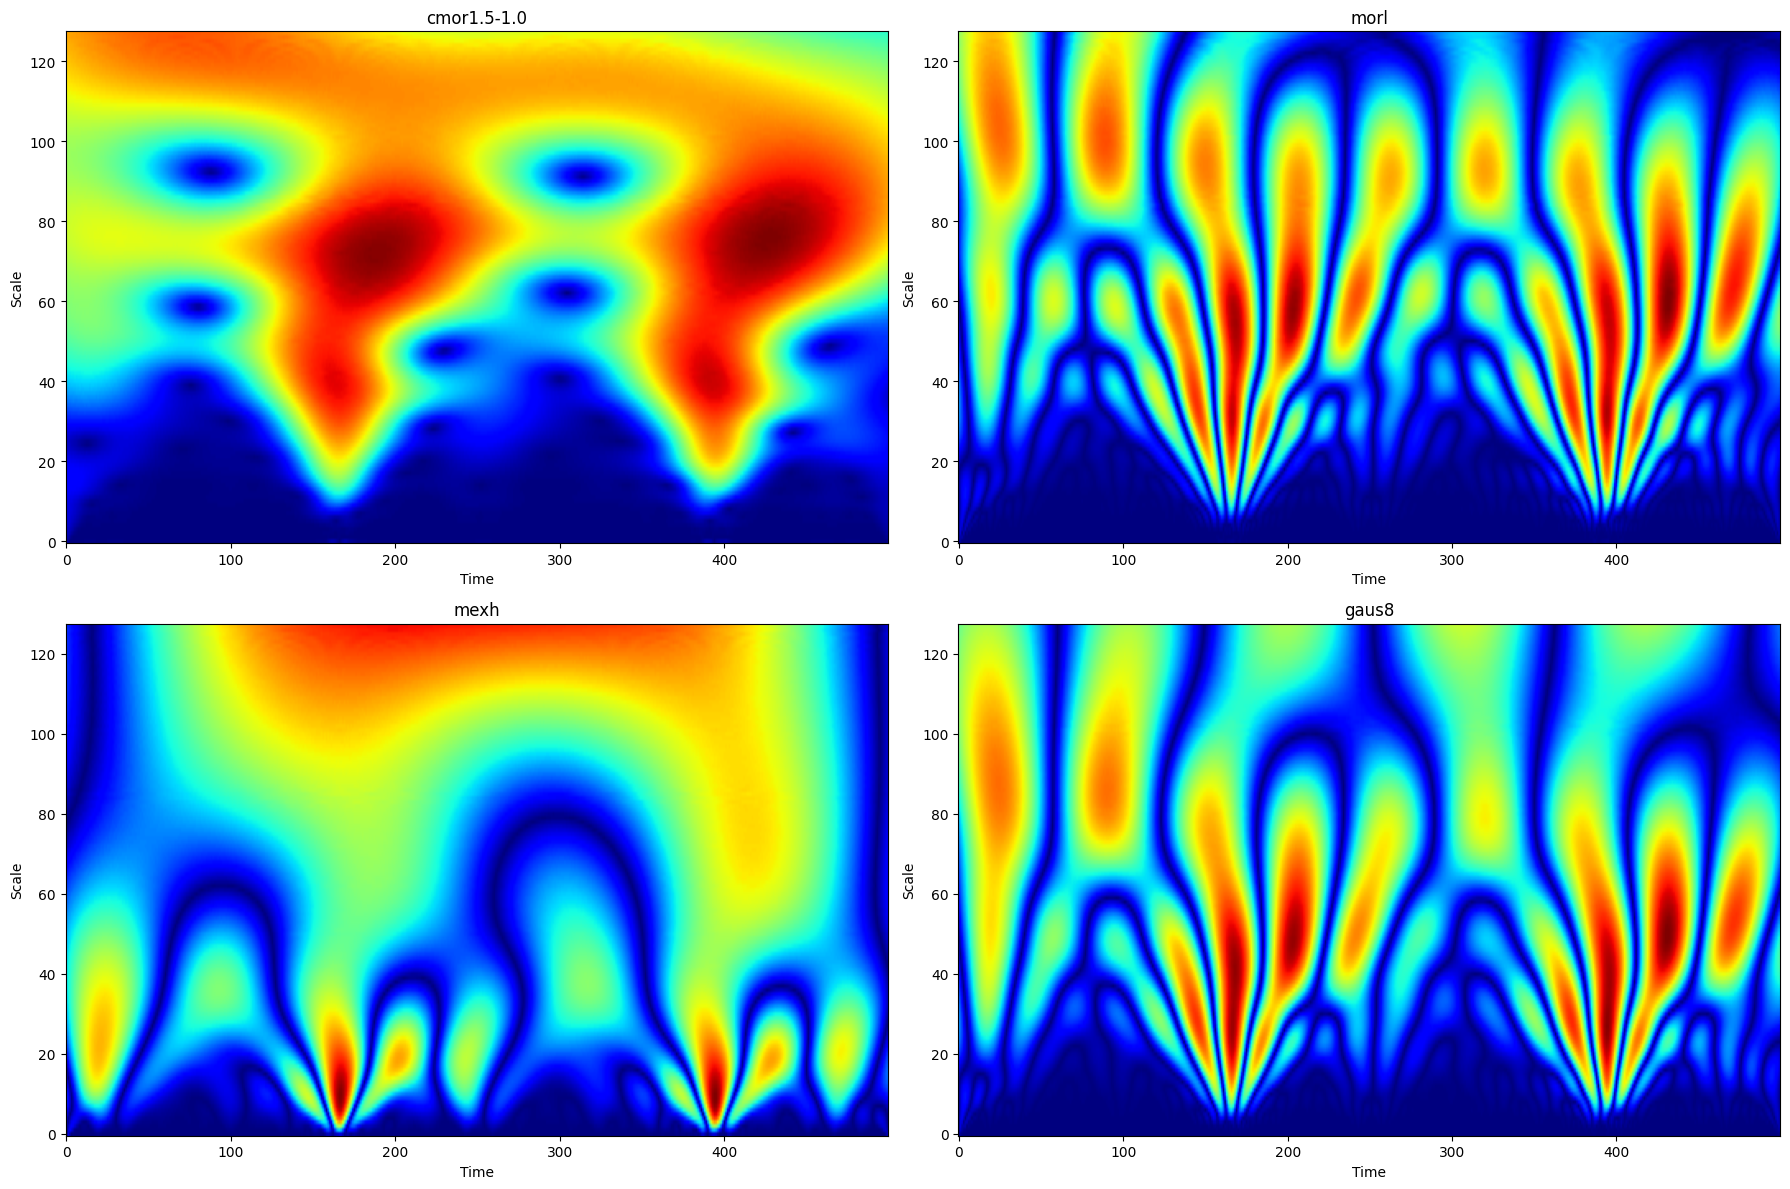

In [20]:
# ============================================================
# Compare Different CWT Wavelets
# ============================================================

wavelets = [
    "cmor1.5-1.0",
    "morl",
    "mexh",
    "gaus8"
]

signal = repair_ecg(X[0])[:, LEAD]
signal = denoise_ecg(signal)

plt.figure(figsize=(18,12))

for i, wavelet in enumerate(wavelets):

    coefficients, frequencies = pywt.cwt(
        signal,
        scales=np.arange(1,129),
        wavelet=wavelet,
        sampling_period=1/FS
    )

    scalogram = np.abs(coefficients)

    scalogram = np.log1p(scalogram)

    scalogram -= scalogram.min()

    scalogram /= scalogram.max()

    plt.subplot(2,2,i+1)

    plt.imshow(
        scalogram,
        origin="lower",
        aspect="auto",
        cmap="jet"
    )

    plt.title(wavelet)

    plt.xlabel("Time")

    plt.ylabel("Scale")

plt.tight_layout()

plt.show()

In [21]:
# ============================================================
# Save Scalogram Image
# ============================================================

from PIL import Image

def save_scalogram_image(
    scalogram,
    save_path
):
    """
    Save normalized scalogram as
    224×224 RGB PNG.
    """

    image = (scalogram * 255).astype(np.uint8)

    image = Image.fromarray(image)

    image = image.resize(
        IMAGE_SIZE,
        Image.BILINEAR
    )

    image = image.convert("RGB")

    image.save(save_path)

In [22]:
# ============================================================
# Generate Wavelet Scalogram Dataset
# ============================================================

for minute in prediction_windows:

    print("\n" + "="*60)
    print(f"Processing {minute} Minute Prediction Window")
    print("="*60)

    X, y = load_dataset(minute)

    positive_folder = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Positive"
    )

    negative_folder = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Negative"
    )

    positive_count = 0
    negative_count = 0
    failed_count = 0

    for idx in tqdm(range(len(X))):

        if y[idx] == 1:

            save_path = os.path.join(
                positive_folder,
                f"{idx:05d}.png"
            )

        else:

            save_path = os.path.join(
                negative_folder,
                f"{idx:05d}.png"
            )

        # Resume capability
        if os.path.exists(save_path):

            if y[idx] == 1:
                positive_count += 1
            else:
                negative_count += 1

            continue

        try:

            # ----------------------------
            # ECG Repair
            # ----------------------------

            ecg = repair_ecg(X[idx])

            signal = ecg[:, LEAD]

            # ----------------------------
            # Wavelet Denoising
            # ----------------------------

            signal = denoise_ecg(signal)

            # ----------------------------
            # Scalogram
            # ----------------------------

            scalogram = generate_scalogram(signal)

            # ----------------------------
            # Normalize
            # ----------------------------

            scalogram = normalize_scalogram(
                scalogram
            )

            # ----------------------------
            # Save
            # ----------------------------

            save_scalogram_image(
                scalogram,
                save_path
            )

            if y[idx] == 1:
                positive_count += 1
            else:
                negative_count += 1

        except Exception as e:

            failed_count += 1

            print(
                f"Failed Sample {idx}: {e}"
            )

    print()

    print(f"Positive Images : {positive_count}")
    print(f"Negative Images : {negative_count}")
    print(f"Failed Images   : {failed_count}")


Processing 30 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0

Processing 25 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0

Processing 20 Minute Prediction Window


...


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0

Processing 10 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0

Processing 5 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0


In [23]:
# ============================================================
# Verify Generated Scalogram Dataset
# ============================================================

for minute in prediction_windows:

    positive_folder = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Positive"
    )

    negative_folder = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Negative"
    )

    positive = len(os.listdir(positive_folder))

    negative = len(os.listdir(negative_folder))

    print(
        f"{minute:>2} min -> "
        f"Positive: {positive:4d}   "
        f"Negative: {negative:4d}"
    )

30 min -> Positive: 1200   Negative: 1200
25 min -> Positive: 1200   Negative: 1200
20 min -> Positive: 1200   Negative: 1200
15 min -> Positive: 1200   Negative: 1200
10 min -> Positive: 1200   Negative: 1200
 5 min -> Positive: 1200   Negative: 1200


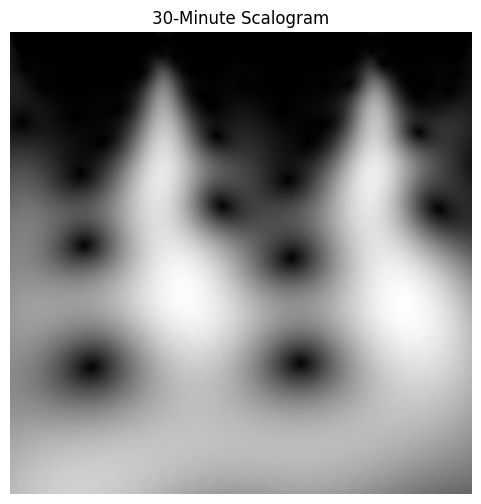

In [24]:
# ============================================================
# Visualize Saved Scalogram Images
# ============================================================

minute = 30

positive_folder = os.path.join(
    OUTPUT_ROOT,
    f"{minute}_min",
    "Positive"
)

sample_file = sorted(
    os.listdir(positive_folder)
)[0]

image = Image.open(
    os.path.join(
        positive_folder,
        sample_file
    )
)

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.axis("off")

plt.title(f"{minute}-Minute Scalogram")

plt.show()